#**Linki do Tableau**
https://public.tableau.com/views/Portfolio1_17873098725820/Przegldsprzeday?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

https://public.tableau.com/views/Portfolio2_17873099332720/Ruchiuytkownicy?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

In [14]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd

project_id = "data-analytics-mate"
client = bigquery.Client(project=project_id)

query = """
SELECT
    s.date                          AS order_date,
    s.ga_session_id                 AS session_id,
    sp.continent                    AS continent,
    sp.country                      AS country,
    sp.device                       AS device,
    sp.browser                      AS browser,
    sp.mobile_model_name            AS device_model_name,
    sp.operating_system             AS operating_system,
    sp.language                     AS browser_language,
    sp.name                         AS traffic_source,
    sp.channel                      AS traffic_channel,
    a.id                            AS registered_user_id,
    a.is_verified                   AS is_email_verified,
    a.is_unsubscribed               AS is_unsubscribed_from_newsletter,
    p.category                      AS product_category,
    p.name                          AS product_name,
    p.price                         AS price,
    p.short_description             AS short_description
FROM `data-analytics-mate.DA.session` AS s
LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
    ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.order` AS o
    ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p
    ON o.item_id = p.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
    ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a
    ON acs.account_id = a.id
"""

df = client.query(query).to_dataframe(create_bqstorage_client=False)
df.head()

,order_date,session_id,continent,country,device,browser,device_model_name,operating_system,browser_language,traffic_source,traffic_channel,registered_user_id,is_email_verified,is_unsubscribed_from_newsletter,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [15]:
# Podstawowe informacje o zbiorze danych
print("Kształt zbioru danych:", df.shape)
print("\nTypy danych:\n", df.dtypes)

# Podział kolumn wg typu
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64', 'dbdate']).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c not in datetime_cols]

print(f"\Liczba kolumn numerycznych: {len(numeric_cols)} -> {numeric_cols}")
print(f"Liczba kolumn daty/czasu: {len(datetime_cols)} -> {datetime_cols}")
print(f"Liczba kolumn kategorycznych: {len(categorical_cols)} -> {categorical_cols}")

# Unikalne sesje
print("\nLiczba unikalnych sesji:", df['session_id'].nunique())

# Zakres dat
print("Okres danych: od", df['order_date'].min(), "do", df['order_date'].max())

# Braki danych
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'braki': missing, 'procent': missing_pct})
print("\nBraki danych:\n", missing_summary[missing_summary['braki'] > 0])

<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_721/2707502338.py:10: SyntaxWarning: invalid escape sequence '\L'
  print(f"\Liczba kolumn numerycznych: {len(numeric_cols)} -> {numeric_cols}")


Kształt zbioru danych: (349545, 18)

Typy danych:
 order_date                          dbdate
session_id                           Int64
continent                           object
country                             object
device                              object
browser                             object
device_model_name                   object
operating_system                    object
browser_language                    object
traffic_source                      object
traffic_channel                     object
registered_user_id                   Int64
is_email_verified                    Int64
is_unsubscribed_from_newsletter      Int64
product_category                    object
product_name                        object
price                              float64
short_description                   object
dtype: object
\Liczba kolumn numerycznych: 5 -> ['session_id', 'registered_user_id', 'is_email_verified', 'is_unsubscribed_from_newsletter', 'price']
Liczba kolumn daty/czasu:

In [16]:
# Jeden wiersz = jeden zamówiony produkt
orders_df = df[df['price'].notna()].copy()

print("Liczba wierszy z zamówieniami:", len(orders_df))
print("Liczba unikalnych sesji z zamówieniem:", orders_df['session_id'].nunique())

Liczba wierszy z zamówieniami: 33538
Liczba unikalnych sesji z zamówieniem: 33538


Top 3 kontynenty wg sprzedaży:
            total_sales  num_orders
continent                         
Americas    17665280.0       18553
Asia         7601298.3        7950
Europe       5934624.2        6261

Top 5 krajów wg sprzedaży:
                 total_sales  num_orders
country                                
United States    13943553.9       14673
India             2809762.0        3029
Canada            2437921.0        2560
United Kingdom     938317.9        1029
France             710692.8         678


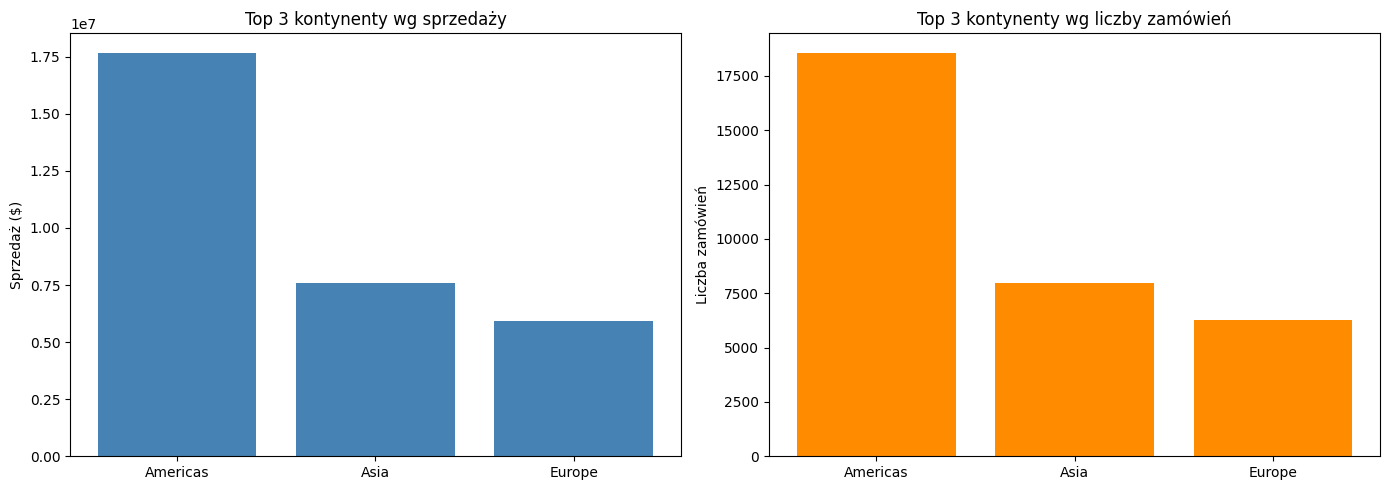

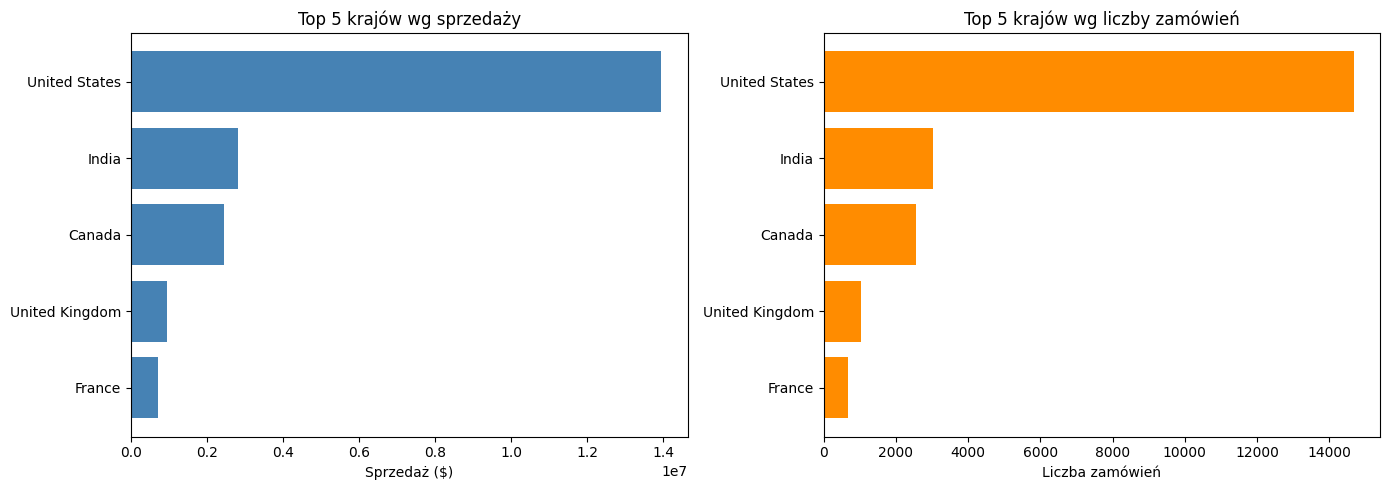

In [17]:
import matplotlib.pyplot as plt

# Sprzedaż i liczba zamówień wg kontynentu
continent_sales = orders_df.groupby('continent').agg(
    total_sales=('price', 'sum'),
    num_orders=('price', 'count')
).sort_values('total_sales', ascending=False)

print("Top 3 kontynenty wg sprzedaży:\n", continent_sales.head(3))

# Sprzedaż i liczba zamówień wg kraju
country_sales = orders_df.groupby('country').agg(
    total_sales=('price', 'sum'),
    num_orders=('price', 'count')
).sort_values('total_sales', ascending=False)

print("\nTop 5 krajów wg sprzedaży:\n", country_sales.head(5))

# Wizualizacja: top 3 kontynenty
top3_continents = continent_sales.head(3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(top3_continents.index, top3_continents['total_sales'], color='steelblue')
axes[0].set_title('Top 3 kontynenty wg sprzedaży')
axes[0].set_ylabel('Sprzedaż ($)')

axes[1].bar(top3_continents.index, top3_continents['num_orders'], color='darkorange')
axes[1].set_title('Top 3 kontynenty wg liczby zamówień')
axes[1].set_ylabel('Liczba zamówień')

plt.tight_layout()
plt.show()

# Wizualizacja: top 5 krajów
top5_countries = country_sales.head(5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top5_countries.index[::-1], top5_countries['total_sales'][::-1], color='steelblue')
axes[0].set_title('Top 5 krajów wg sprzedaży')
axes[0].set_xlabel('Sprzedaż ($)')

axes[1].barh(top5_countries.index[::-1], top5_countries['num_orders'][::-1], color='darkorange')
axes[1].set_title('Top 5 krajów wg liczby zamówień')
axes[1].set_xlabel('Liczba zamówień')

plt.tight_layout()
plt.show()

##**Wnioski**
Ameryka zdecydowanie dominuje sprzedażowo (17,7 mln, 18 553 zamówienia), generując niemal 2,3x więcej sprzedaży niż Azja i 3x więcej niż Europa. Ta sama kolejność utrzymuje się zarówno pod względem wartości sprzedaży, jak i liczby zamówień. Na poziomie krajów Stany Zjednoczone odpowiadają za ponad 60% całkowitej sprzedaży (13,9 mln), znacznie wyprzedzając Indie i Kanadę.

Top 10 kategorii produktów wg sprzedaży:
                                   total_sales  num_orders
product_category                                         
Sofas & armchairs                   8388254.5        4301
Chairs                              6147748.8        5952
Beds                                4919725.0        2926
Bookcases & shelving units          3640818.1        7630
Cabinets & cupboards                2336499.5        2318
Outdoor furniture                   2142222.2        2229
Tables & desks                      1790307.5        2941
Chests of drawers & drawer units     906562.5        1452
Bar furniture                        735503.0        1092
Children's furniture                 467697.0        1702

Kraj z najwyższą sprzedażą: United States

Top 10 kategorii produktów w United States:
                                   total_sales  num_orders
product_category                                         
Sofas & armchairs                   3707144.5        1903

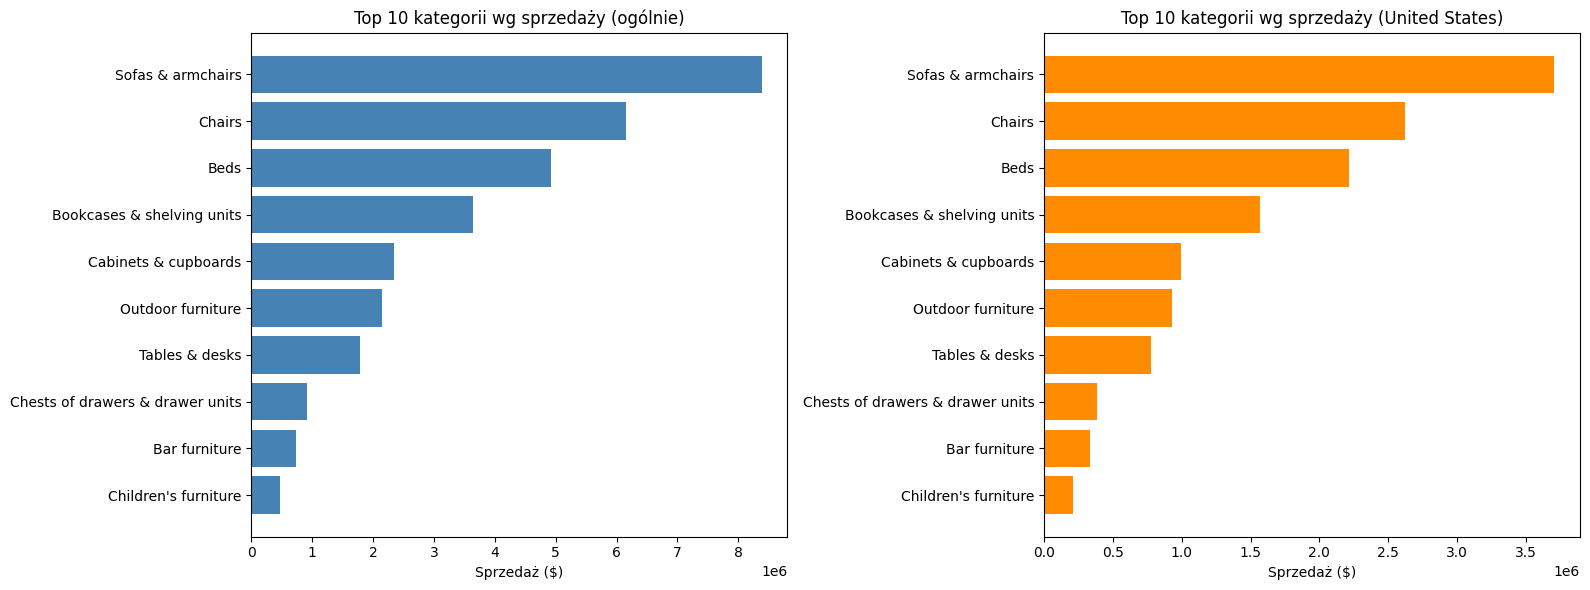

In [18]:
# Top 10  kategorii produktów wg całkowitej sprzedaży
category_sales = orders_df.groupby('product_category').agg(
    total_sales=('price', 'sum'),
    num_orders=('price', 'count')
).sort_values('total_sales', ascending=False)

top10_categories = category_sales.head(10)
print("Top 10 kategorii produktów wg sprzedaży:\n", top10_categories)

# Top 10 kategorii w kraju z najwyższą spzredażą
top_country = country_sales.index[0]
print(f"\nKraj z najwyższą sprzedażą: {top_country}")

orders_top_country = orders_df[orders_df['country'] == top_country]
category_sales_top_country = orders_top_country.groupby('product_category').agg(
    total_sales=('price', 'sum'),
    num_orders=('price', 'count')
).sort_values('total_sales', ascending=False)

top10_categories_country = category_sales_top_country.head(10)
print(f"\nTop 10 kategorii produktów w {top_country}:\n", top10_categories_country)

# Wizualizacja porównawcza
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10_categories.index[::-1], top10_categories['total_sales'][::-1], color='steelblue')
axes[0].set_title('Top 10 kategorii wg sprzedaży (ogólnie)')
axes[0].set_xlabel('Sprzedaż ($)')

axes[1].barh(top10_categories_country.index[::-1], top10_categories_country['total_sales'][::-1], color='darkorange')
axes[1].set_title(f'Top 10 kategorii wg sprzedaży ({top_country})')
axes[1].set_xlabel('Sprzedaż ($)')

plt.tight_layout()
plt.show()

##**Wnioski**
Sofy i fotele generują najwyższą sprzedaż (8,4 mln), mimo że mają mniej zamówień (4301) niż np. Bookcases & shelving units (7630 zamówień, ale tylko 3,6 mln sprzedaży). Pokazuje to wyraźnie wyższą średnią wartość zamówienia w kategoriach mebli dużych w porównaniu do mniejszych produktów. Ranking kategorii w Stanach Zjednoczonych pokrywa się niemal co do jednego z rankingiem globalnym.

Sprzedaż wg urządzenia (%):
 device
desktop    59.00
mobile     38.73
tablet      2.26
Name: price, dtype: float64

Top 10 modeli urządzeń wg sprzedaży (%):
 device_model_name
Chrome        27.84
<Other>       20.44
Safari        20.30
iPhone        20.08
ChromeBook     5.73
Edge           2.18
iPad           1.40
Firefox        1.32
Pixel 4 XL     0.37
Pixel 3        0.34
Name: price, dtype: float64

Sprzedaż wg kanału ruchu (%):
 traffic_channel
Organic Search    35.76
Paid Search       26.62
Direct            23.44
Social Search      7.92
Undefined          6.26
Name: price, dtype: float64


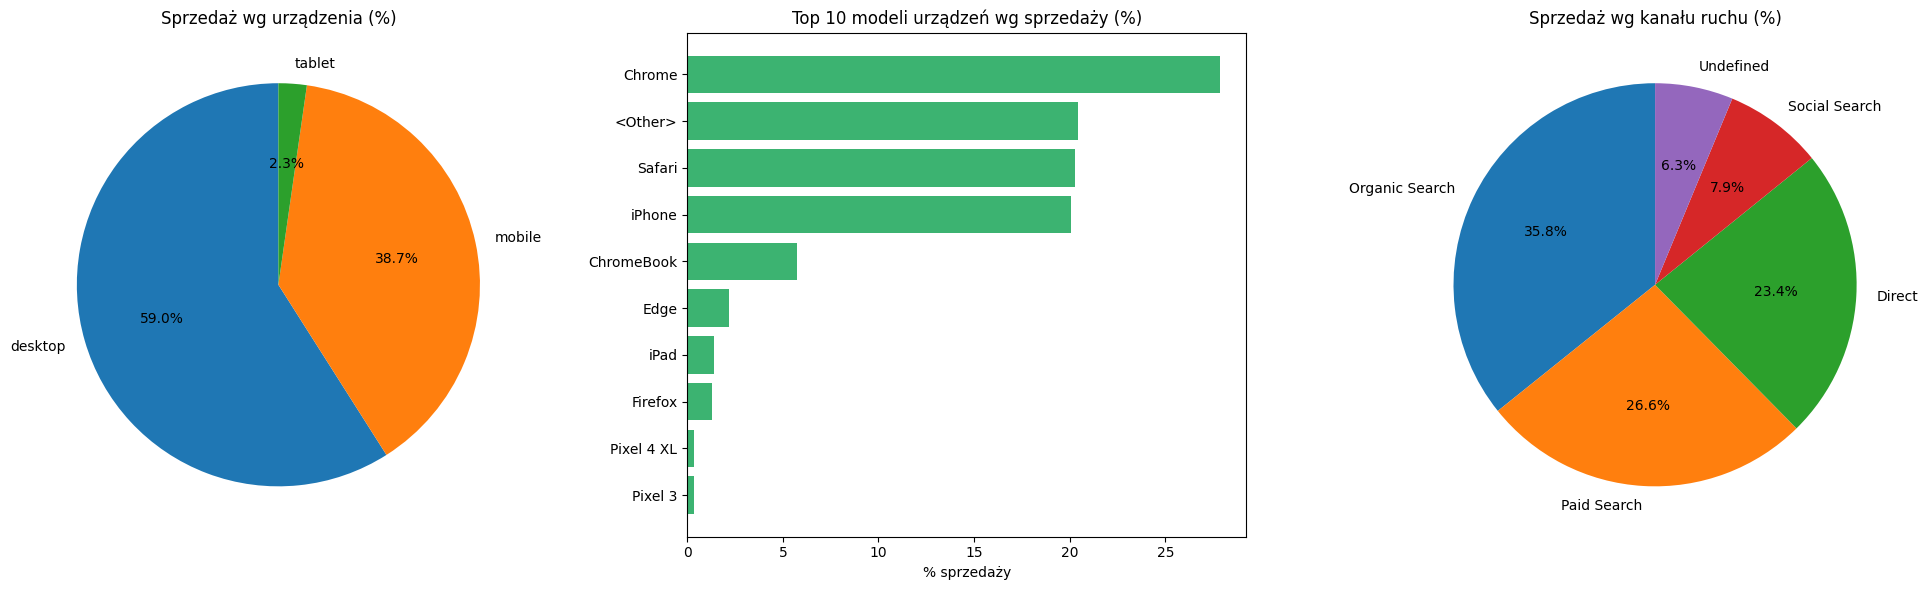

In [19]:
# Sprzedaż wg typu urządzenia (% całości)
device_sales = orders_df.groupby('device')['price'].sum().sort_values(ascending=False)
device_sales_pct = (device_sales / device_sales.sum() * 100).round(2)

print("Sprzedaż wg urządzenia (%):\n", device_sales_pct)

# Sprzedaż wg modelu urządzenia (% całości, top 10)
model_sales = orders_df.groupby('device_model_name')['price'].sum().sort_values(ascending=False)
model_sales_pct = (model_sales / model_sales.sum() * 100).round(2)

print("\nTop 10 modeli urządzeń wg sprzedaży (%):\n", model_sales_pct.head(10))

# Sprzedaż wg źródła ruchu (% całości)
traffic_sales = orders_df.groupby('traffic_channel')['price'].sum().sort_values(ascending=False)
traffic_sales_pct = (traffic_sales / traffic_sales.sum() * 100).round(2)

print("\nSprzedaż wg kanału ruchu (%):\n", traffic_sales_pct)

# Wizualizacje
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].pie(device_sales_pct, labels=device_sales_pct.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Sprzedaż wg urządzenia (%)')

axes[1].barh(model_sales_pct.head(10).index[::-1], model_sales_pct.head(10).values[::-1], color='mediumseagreen')
axes[1].set_title('Top 10 modeli urządzeń wg sprzedaży (%)')
axes[1].set_xlabel('% sprzedaży')

axes[2].pie(traffic_sales_pct, labels=traffic_sales_pct.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Sprzedaż wg kanału ruchu (%)')

plt.tight_layout()
plt.show()

##**Wnioski**
Desktop odpowiada za 59% sprzedaży, mobile za 38,7%, a tablet jedynie za 2,3%.
Ruch organiczny generuje najwięcej sprzedaży (35,8%), a płatne wyszukiwanie tuż za nim (26,6%). Razem odpowiadają za ponad 60% przychodu.

Liczba unikalnych zarejestrowanych użytkowników: 27945
Procent użytkowników z potwierdzonym e-mailem: 71.7%
Procent użytkowników, którzy zrezygnowali z newslettera: 16.94%


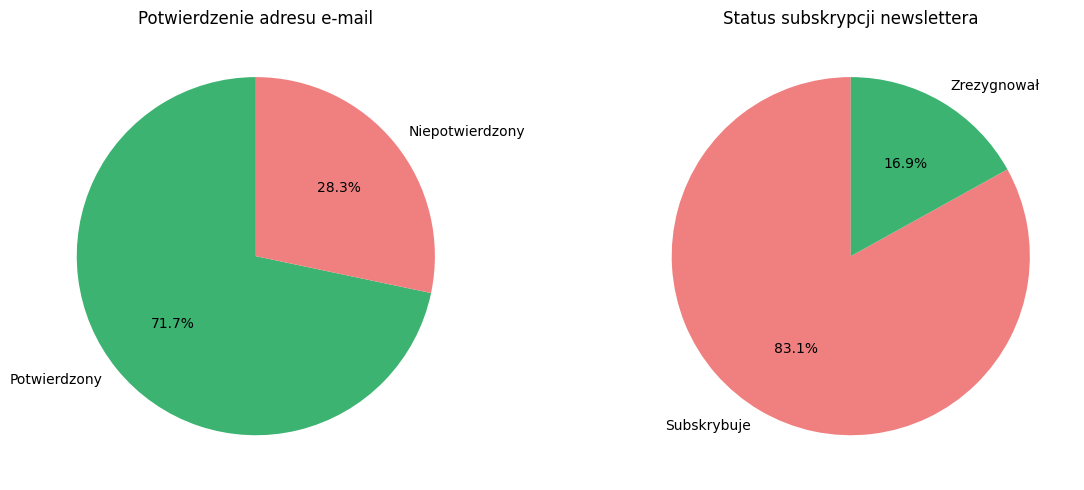

In [20]:
# Tylko zarejestrowani użytkownicy
registered_users = df[df['registered_user_id'].notna()].drop_duplicates(subset='registered_user_id')

print("Liczba unikalnych zarejestrowanych użytkowników:", len(registered_users))

# % potwierdzonych e-maili
verified_pct = (registered_users['is_email_verified'].sum() / len(registered_users) * 100).round(2)
print(f"Procent użytkowników z potwierdzonym e-mailem: {verified_pct}%")

# % rezygnacji z newslettera
unsubscribed_pct = (registered_users['is_unsubscribed_from_newsletter'].sum() / len(registered_users) * 100).round(2)
print(f"Procent użytkowników, którzy zrezygnowali z newslettera: {unsubscribed_pct}%")
# WIzualizacja
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

verified_counts = registered_users['is_email_verified'].value_counts()
axes[0].pie(verified_counts, labels=['Potwierdzony', 'Niepotwierdzony'] if verified_counts.index[0]==1 else ['Niepotwierdzony', 'Potwierdzony'],
            autopct='%1.1f%%', startangle=90, colors=['mediumseagreen', 'lightcoral'])
axes[0].set_title('Potwierdzenie adresu e-mail')

unsub_counts = registered_users['is_unsubscribed_from_newsletter'].value_counts()
axes[1].pie(unsub_counts, labels=['Zrezygnował', 'Subskrybuje'] if unsub_counts.index[0]==1 else ['Subskrybuje', 'Zrezygnował'],
            autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'mediumseagreen'])
axes[1].set_title('Status subskrypcji newslettera')

plt.tight_layout()
plt.show()


##**Wnioski**
Wśród 27 945 zarejestrowanych użytkowników 71,7% potwierdziło adres e-mail, co oznacza, że blisko 30% kont pozostaje niezweryfikowanych.

Porównanie zachowań sprzedażowych wg statusu newlettera:
                                  avg_total_spent  avg_num_orders  \
is_unsubscribed_from_newsletter                                    
Subskrybuje                           921.506812             1.0   
Zrezygnował                           965.820134             1.0   

                                 median_total_spent  num_users  
is_unsubscribed_from_newsletter                                 
Subskrybuje                                   395.0       2334  
Zrezygnował                                   450.0        447  


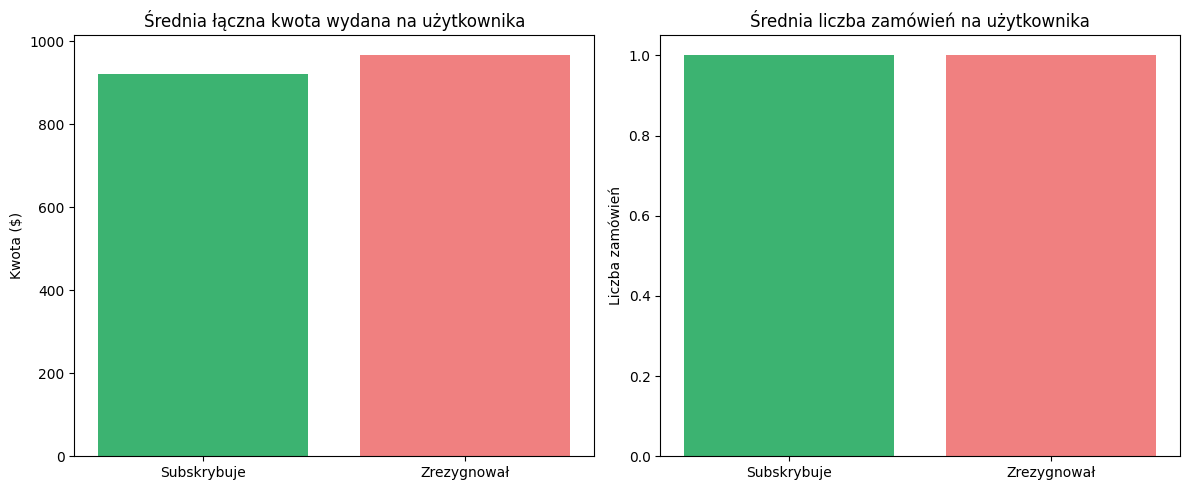

In [22]:
# Zarejestrowani użytkownicy z zamówieniami
registered_orders = orders_df[orders_df['registered_user_id'].notna()].copy()

# Agregacja na poziomie użytkownika
user_summary = registered_orders.groupby(['registered_user_id', 'is_unsubscribed_from_newsletter']).agg(
    total_spent=('price', 'sum'),
    num_orders=('price', 'count')
).reset_index()

# Porównanie średnich metryk między grupami
group_comparison = user_summary.groupby('is_unsubscribed_from_newsletter').agg(
    avg_total_spent=('total_spent', 'mean'),
    avg_num_orders=('num_orders', 'mean'),
    median_total_spent=('total_spent', 'median'),
    num_users=('registered_user_id', 'count')
)

group_comparison.index = group_comparison.index.map({0: 'Subskrybuje', 1: 'Zrezygnował'})
print("Porównanie zachowań sprzedażowych wg statusu newlettera:\n", group_comparison)

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(group_comparison.index, group_comparison['avg_total_spent'], color=['mediumseagreen', 'lightcoral'])
axes[0].set_title('Średnia łączna kwota wydana na użytkownika')
axes[0].set_ylabel('Kwota ($)')

axes[1].bar(group_comparison.index, group_comparison['avg_num_orders'], color=['mediumseagreen', 'lightcoral'])
axes[1].set_title('Średnia liczba zamówień na użytkownika')
axes[1].set_ylabel('Liczba zamówień')

plt.tight_layout()
plt.show()

##**Wnioski**
Osoby, które zrezygnowały z newslettera, wydały średnio więcej (965,8  vs 921,5 ) i miały wyższą medianę wydatków (450  vs 395 ) niż aktywni subskrybenci, choć liczba zamówień na użytkownika jest identyczna w obu grupach (1,0).

Top 10 krajów wg liczby zarejestrowanych użytkowników:
 country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Spain               536
Taiwan              500
China               490
Germany             490
Italy               386
Name: registered_user_id, dtype: int64


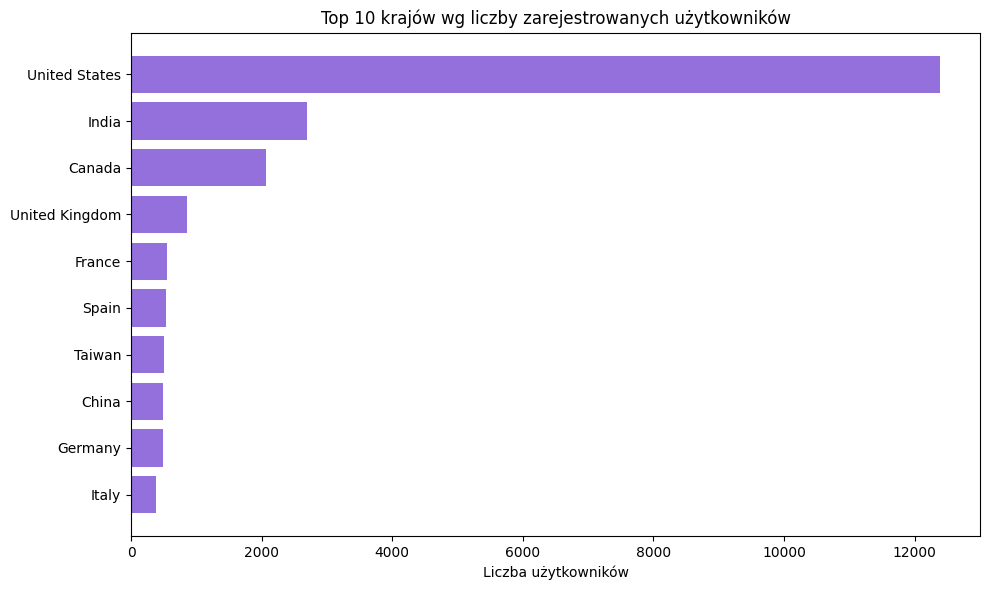

In [23]:
# Liczba zarejstrowanych użytkowników wg kraju

registered_df = df[df['registered_user_id'].notna()].copy()

users_by_country = registered_df.drop_duplicates(subset=['registered_user_id', 'country']) \
    .groupby('country')['registered_user_id'].nunique() \
    .sort_values(ascending=False)

top10_users_by_country = users_by_country.head(10)
print("Top 10 krajów wg liczby zarejestrowanych użytkowników:\n", top10_users_by_country)

# Wizualizacja
plt.figure(figsize=(10, 6))
plt.barh(top10_users_by_country.index[::-1], top10_users_by_country.values[::-1], color='mediumpurple')
plt.title('Top 10 krajów wg liczby zarejestrowanych użytkowników')
plt.xlabel('Liczba użytkowników')
plt.tight_layout()
plt.show()

##**Wnioski**
Ranking krajów wg liczby zarejestrowanych użytkowników (USA, Indie, Kanada, UK, Francja) pokrywa się niemal dokładnie z rankingiem tych samych krajów wg sprzedaży.

Zakres dat: 2020-11-01 00:00:00 - 2021-01-27 00:00:00
Liczba dni z danymi: 88


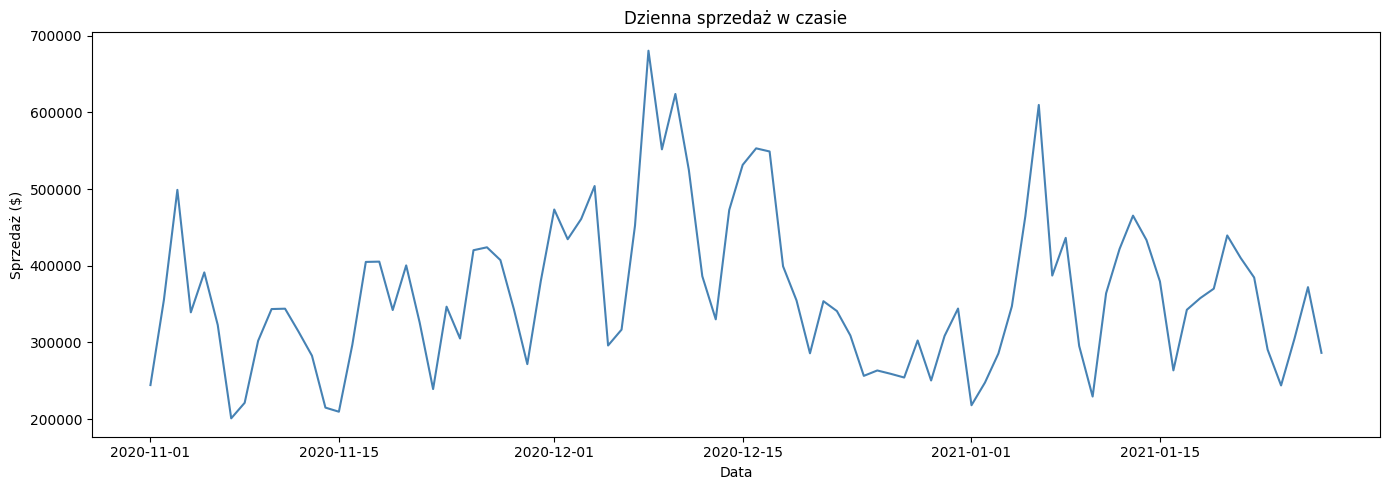

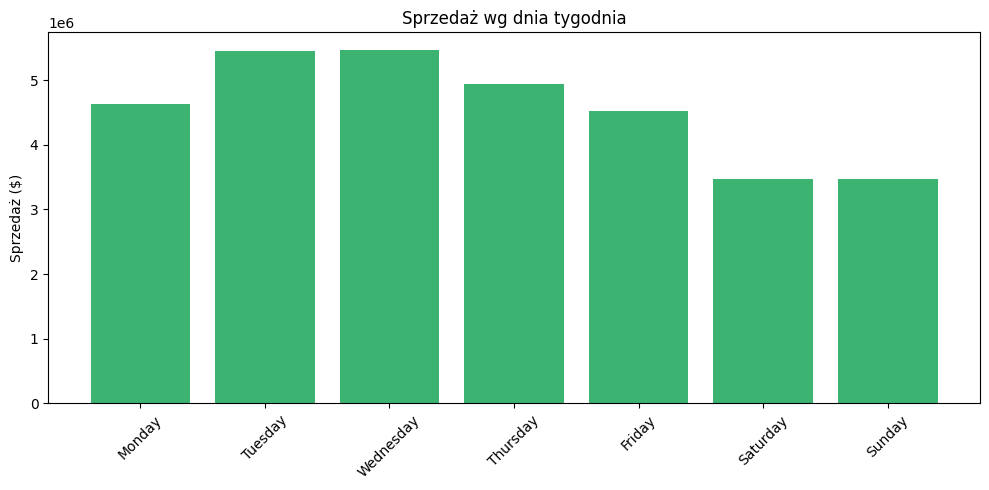

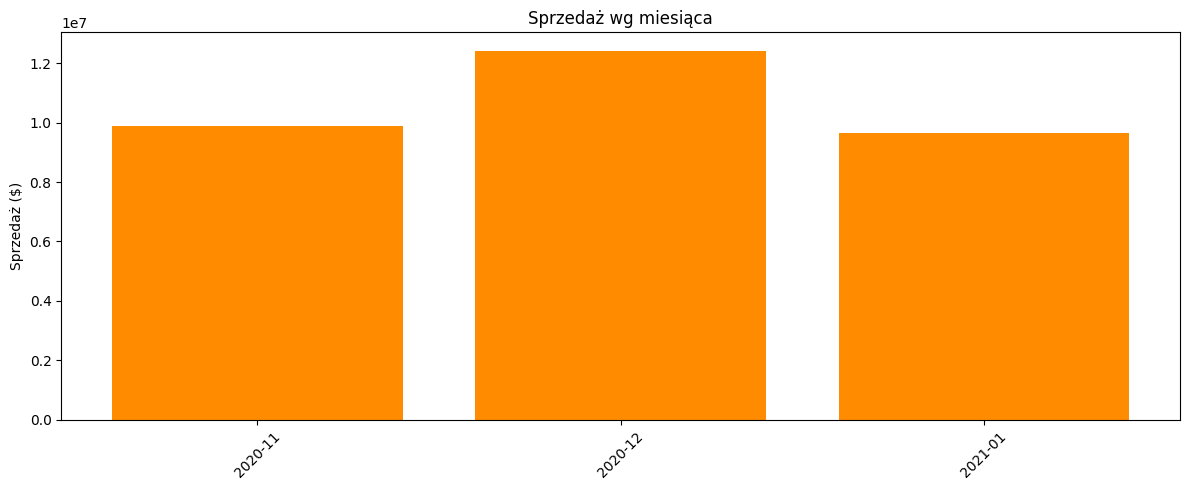

In [24]:
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

# Całkowita sprzedaż wg daty
daily_sales = orders_df.groupby('order_date')['price'].sum().sort_index()

print("Zakres dat:", daily_sales.index.min(), "-", daily_sales.index.max())
print("Liczba dni z danymi:", len(daily_sales))

# Wizualizacja ogólnej dynamiki
plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values, color='steelblue')
plt.title('Dzienna sprzedaż w czasie')
plt.xlabel('Data')
plt.ylabel('Sprzedaż ($)')
plt.tight_layout()
plt.show()

# Sprawdzenie sezonowości: sprzedaż wg dnia tygodnia
orders_df['day_of_week'] = orders_df['order_date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = orders_df.groupby('day_of_week')['price'].sum().reindex(weekday_order)

plt.figure(figsize=(10, 5))
plt.bar(weekday_sales.index, weekday_sales.values, color='mediumseagreen')
plt.title('Sprzedaż wg dnia tygodnia')
plt.ylabel('Sprzedaż ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sprawdzenie sezonowości: sprzedaż wg miesiąca
orders_df['month'] = orders_df['order_date'].dt.to_period('M').astype(str)
monthly_sales = orders_df.groupby('month')['price'].sum()

plt.figure(figsize=(12, 5))
plt.bar(monthly_sales.index, monthly_sales.values, color='darkorange')
plt.title('Sprzedaż wg miesiąca')
plt.ylabel('Sprzedaż ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**Wnioski**
Widoczna jest wyraźna sezonowość tygodniowa: wtorek i środa generują najwyższą sprzedaż, a weekendy (sobota, niedziela) najniższą.
W ujęciu miesięcznym grudzień 2020 wyraźnie dominuje nad listopadem i styczniem , co może wskazywać na efekt sezonu świąteczno-noworocznego.

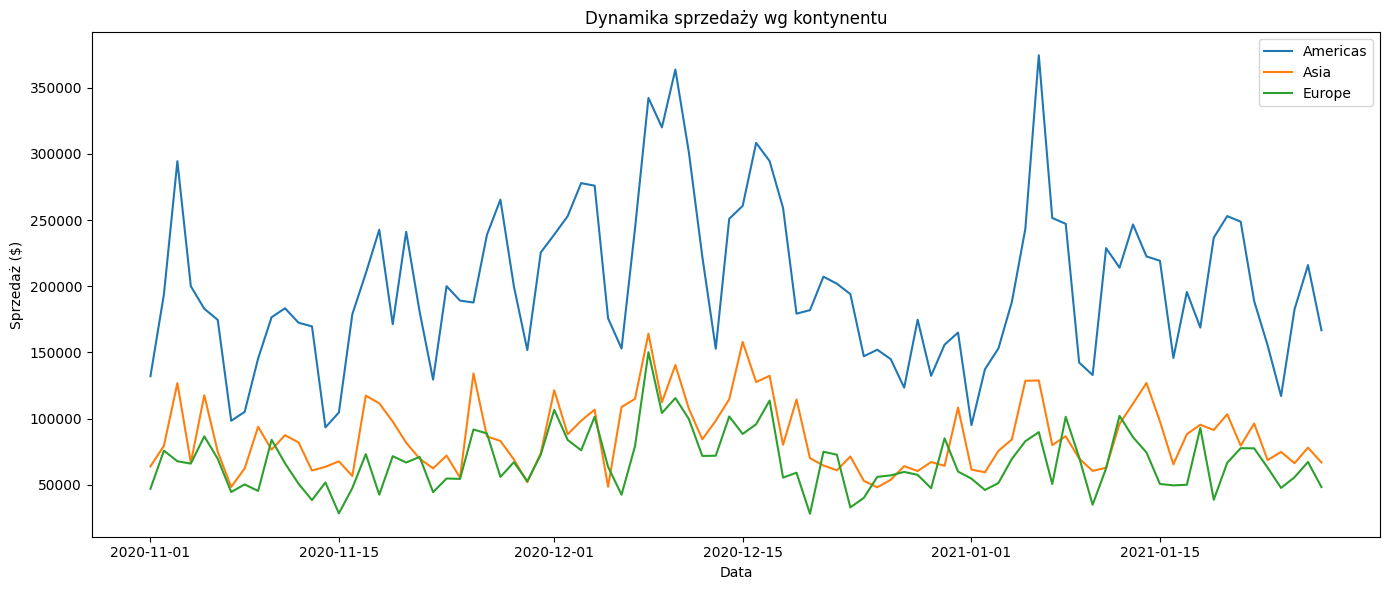

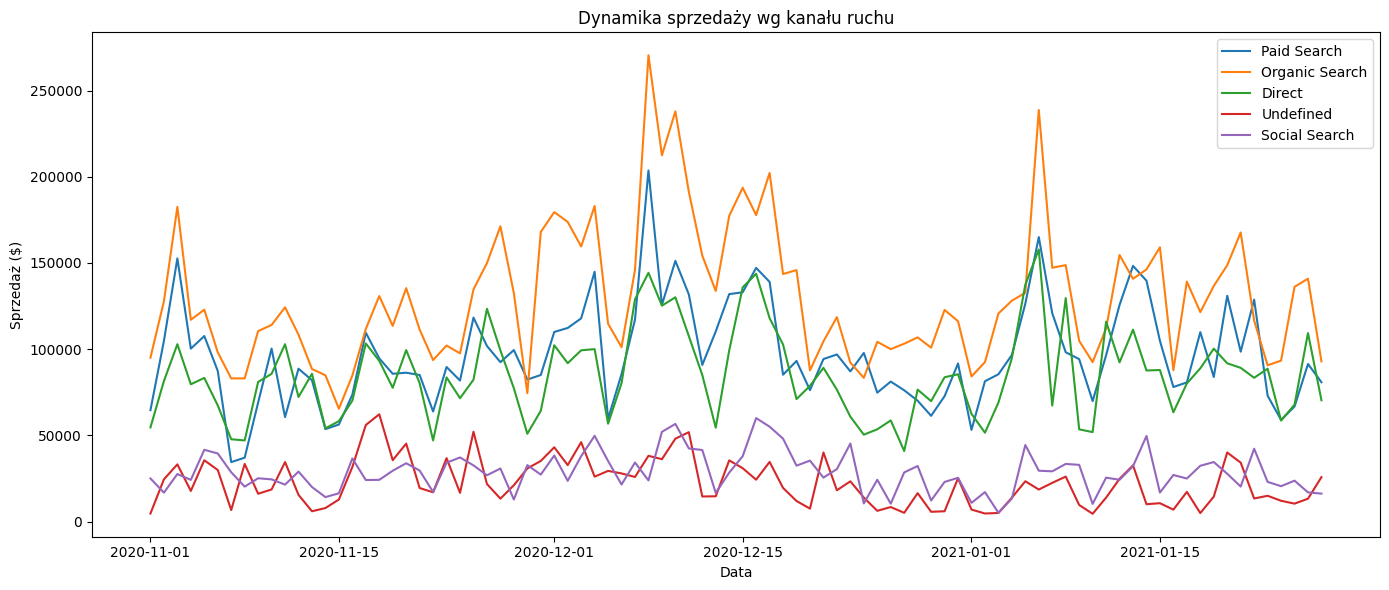

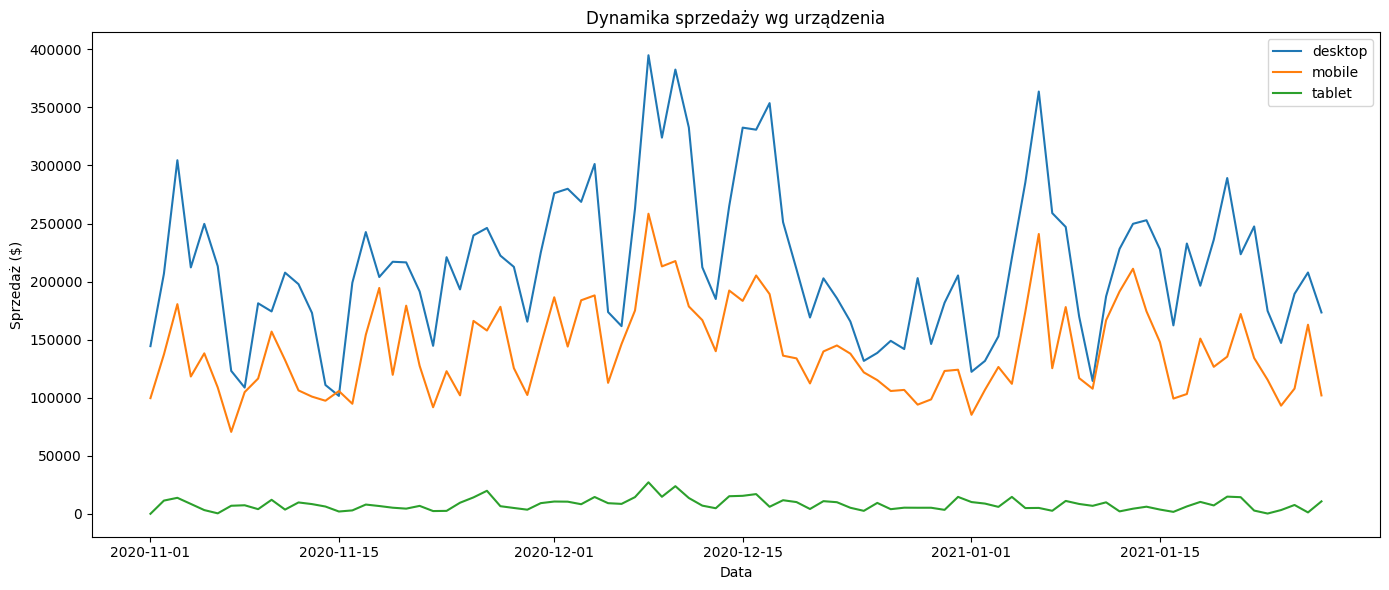

In [25]:
# Dynamika sprzedaży: Ameryka, Azja, Europa
target_continents = ['Americas', 'Asia', 'Europe']
continent_daily = orders_df[orders_df['continent'].isin(target_continents)] \
    .groupby(['order_date', 'continent'])['price'].sum().reset_index()

plt.figure(figsize=(14, 6))
for continent in target_continents:
    subset = continent_daily[continent_daily['continent'] == continent]
    plt.plot(subset['order_date'], subset['price'], label=continent)

plt.title('Dynamika sprzedaży wg kontynentu')
plt.xlabel('Data')
plt.ylabel('Sprzedaż ($)')
plt.legend()
plt.tight_layout()
plt.show()

# Dynamika sprzedaży wg kanału ruchu
channel_daily = orders_df.groupby(['order_date', 'traffic_channel'])['price'].sum().reset_index()

plt.figure(figsize=(14, 6))
for channel in orders_df['traffic_channel'].dropna().unique():
    subset = channel_daily[channel_daily['traffic_channel'] == channel]
    plt.plot(subset['order_date'], subset['price'], label=channel)

plt.title('Dynamika sprzedaży wg kanału ruchu')
plt.xlabel('Data')
plt.ylabel('Sprzedaż ($)')
plt.legend()
plt.tight_layout()
plt.show()

# Dynamika sprzedaży wg urządzenia
device_daily = orders_df.groupby(['order_date', 'device'])['price'].sum().reset_index()

plt.figure(figsize=(14, 6))
for device in orders_df['device'].dropna().unique():
    subset = device_daily[device_daily['device'] == device]
    plt.plot(subset['order_date'], subset['price'], label=device)

plt.title('Dynamika sprzedaży wg urządzenia')
plt.xlabel('Data')
plt.ylabel('Sprzedaż ($)')
plt.legend()
plt.tight_layout()
plt.show()

##**Wnioski**
We wszystkich trzech przekrojach (kontynent, kanał ruchu, urządzenie) widoczny jest ten sam wzorzec: wyraźny skok sprzedaży w połowie grudnia oraz cykliczne, tygodniowe wahania utrzymujące się przez cały okres. Ameryka, ruch organiczny i desktop konsekwentnie utrzymują przewagę nad pozostałymi kategoriami przez cały analizowany okres. Nie ma widocznych zmian w hierarchii liderów w czasie.

Liczba sesji wg kanału ruchu i typu urządzenia:
 device           desktop  mobile  tablet
traffic_channel                         
Direct             47825   31745    1812
Organic Search     72622   49014    2789
Paid Search        55167   37034    2140
Social Search      16288   10988     638
Undefined          12527    8486     470

Sprzedaż wg kategorii produktów (top 10) i krajów (top 5):
 country                             Canada    France     India  \
product_category                                                 
Sofas & armchairs                 692427.5  187735.0  788430.0   
Chairs                            417740.8  134029.4  544309.2   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Outdoor furniture                 185322.8   40486.4  162289.4   
Tables & desks                    132678.0   42299.0  186157.5   
Chests of

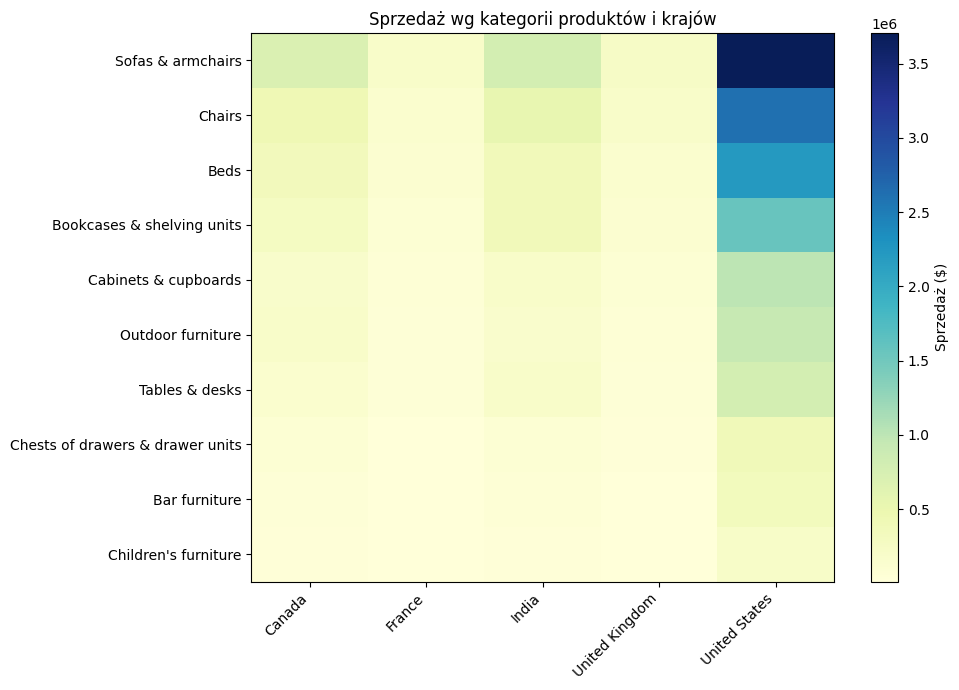


Liczba zamówień wg urządzenia i kraju (top 5):
 country  Canada  France  India  United Kingdom  United States
device                                                       
desktop    1510     400   1813             606           8594
mobile     1006     267   1150             402           5745
tablet       44      11     66              21            334

Średnia wartość zamówienia wg kategorii i urządzenia:
 device                            desktop   mobile   tablet
product_category                                           
Bar furniture                      668.83   686.38   583.08
Beds                              1708.85  1646.09  1612.55
Bookcases & shelving units         479.98   473.54   468.12
Cabinets & cupboards              1001.67  1006.66  1201.67
Chairs                            1058.55   984.08  1186.81
Chests of drawers & drawer units   627.39   617.69   668.26
Children's furniture               276.46   269.90   319.91
Outdoor furniture                  958.85   9

In [26]:
# Tabela przestawna 1: liczba sesji wg kanału ruchu i typu urządzenia

sessions_clean = df.dropna(subset=['traffic_channel', 'device'])
sessions_clean = sessions_clean[
    (sessions_clean['traffic_channel'].str.lower() != 'unknown') &
    (sessions_clean['device'].str.lower() != 'unknown')
]

pivot_sessions = sessions_clean.drop_duplicates(subset='session_id').pivot_table(
    index='traffic_channel',
    columns='device',
    values='session_id',
    aggfunc='nunique',
    fill_value=0
)
print("Liczba sesji wg kanału ruchu i typu urządzenia:\n", pivot_sessions)

# Tabela przestawna 2: sprzedaż wg kategorii produktów (top 10) i krajów (top 5)
top10_cat_list = top10_categories.index.tolist()
top5_country_list = country_sales.head(5).index.tolist()

orders_filtered = orders_df[
    orders_df['product_category'].isin(top10_cat_list) &
    orders_df['country'].isin(top5_country_list)
]

pivot_sales = orders_filtered.pivot_table(
    index='product_category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0
).round(2)

# Sortujemy wiersze wg total sales malejąco
pivot_sales = pivot_sales.reindex(top10_cat_list)

print("\nSprzedaż wg kategorii produktów (top 10) i krajów (top 5):\n", pivot_sales)

# Wizualizacja tabeli 2 jako heatmapa
plt.figure(figsize=(10, 7))
plt.imshow(pivot_sales, cmap='YlGnBu', aspect='auto')
plt.colorbar(label='Sprzedaż ($)')
plt.xticks(range(len(pivot_sales.columns)), pivot_sales.columns, rotation=45, ha='right')
plt.yticks(range(len(pivot_sales.index)), pivot_sales.index)
plt.title('Sprzedaż wg kategorii produktów i krajów')
plt.tight_layout()
plt.show()

# Własna tabela 3: liczba zamówień wg urządzenia i kraju (top 5)

pivot_device_country = orders_df[orders_df['country'].isin(top5_country_list)].pivot_table(
    index='device',
    columns='country',
    values='price',
    aggfunc='count',
    fill_value=0
)
print("\nLiczba zamówień wg urządzenia i kraju (top 5):\n", pivot_device_country)

# Własna tabela 4: średnia cena produktu wg kategorii i urządzenia

pivot_avg_price = orders_df[orders_df['product_category'].isin(top10_cat_list)].pivot_table(
    index='product_category',
    columns='device',
    values='price',
    aggfunc='mean',
    fill_value=0
).round(2)
print("\nŚrednia wartość zamówienia wg kategorii i urządzenia:\n", pivot_avg_price)

##**Wnioski**
Kombinacja Organic Search z desktop generuje zdecydowanie najwięcej sesji (72 622), potwierdzając wcześniejszą obserwację o dominacji wyszukiwania organicznego i komputerów stacjonarnych. W tabeli sprzedaży wg kategorii i krajów Stany Zjednoczone dominują niemal w każdej kategorii produktowej, a sofy i fotele w USA to pojedyncza najwyższa wartość w całej macierzy (3,7 mln ). Dodatkowa tabela ze średnią wartością zamówienia pokazuje, że kategoria Sofas & armchairs ma też najwyższą średnią wartość zamówienia (ok. 1940-1965  w zależności od urządzenia), a Children's furniture najniższą (276-319 ).

Korelacja: liczba sesji vs sprzedaż -> r = 0.931, p-value = 0.00000
-> Korelacja istotna statystycznie (p < 0.05)


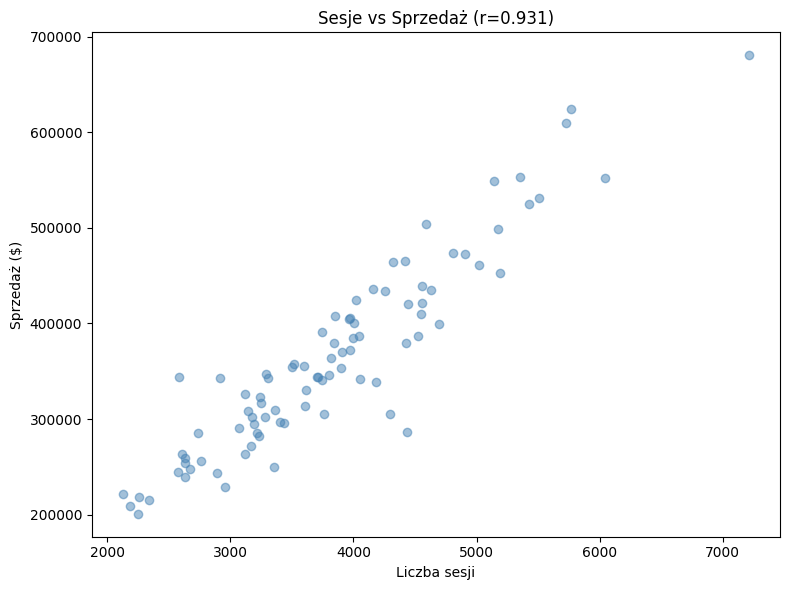


Macierz korelacji sprzedaży między kontynentami:
 continent  Americas   Asia  Europe
continent                         
Americas      1.000  0.692   0.670
Asia          0.692  1.000   0.668
Europe        0.670  0.668   1.000
Americas vs Asia: r=0.692, p=0.00000 (istotna)
Americas vs Europe: r=0.670, p=0.00000 (istotna)
Asia vs Europe: r=0.668, p=0.00000 (istotna)

Macierz korelacji sprzedaży między kanałami ruchu:
 traffic_channel  Direct  Organic Search  Paid Search  Social Search  Undefined
traffic_channel                                                               
Direct            1.000           0.760        0.724          0.462      0.424
Organic Search    0.760           1.000        0.808          0.434      0.435
Paid Search       0.724           0.808        1.000          0.452      0.430
Social Search     0.462           0.434        0.452          1.000      0.359
Undefined         0.424           0.435        0.430          0.359      1.000
Organic Search vs Paid Sear

In [32]:
from scipy import stats
import numpy as np

# 1. Liczba sesji i sprzedaż wg daty
daily_sessions = df.drop_duplicates(subset='session_id').groupby('order_date')['session_id'].nunique()
daily_sales_full = orders_df.groupby('order_date')['price'].sum()

daily_combined = pd.DataFrame({
    'sessions': daily_sessions,
    'sales': daily_sales_full
}).dropna()

corr, p_value = stats.pearsonr(daily_combined['sessions'], daily_combined['sales'])
print(f"Korelacja: liczba sesji vs sprzedaż -> r = {corr:.3f}, p-value = {p_value:.5f}")
if p_value < 0.05:
    print("-> Korelacja istotna statystycznie (p < 0.05)")
else:
    print("-> Korelacja NIEistotna statystycznie (p >= 0.05)")

plt.figure(figsize=(8, 6))
plt.scatter(daily_combined['sessions'], daily_combined['sales'], alpha=0.5, color='steelblue')
plt.title(f'Sesje vs Sprzedaż (r={corr:.3f})')
plt.xlabel('Liczba sesji')
plt.ylabel('Sprzedaż ($)')
plt.tight_layout()
plt.show()

# 2. Korelacja sprzedaży między top 3 kontynentami
continent_pivot = orders_df[orders_df['continent'].isin(target_continents)] \
    .groupby(['order_date', 'continent'])['price'].sum().unstack(fill_value=0)

print("\nMacierz korelacji sprzedaży między kontynentami:\n", continent_pivot.corr().round(3))

# Testy istotności dla każdej pary
for i in range(len(target_continents)):
    for j in range(i+1, len(target_continents)):
        c1, c2 = target_continents[i], target_continents[j]
        r, p = stats.pearsonr(continent_pivot[c1], continent_pivot[c2])
        sig = "istotna" if p < 0.05 else "NIEistotna"
        print(f"{c1} vs {c2}: r={r:.3f}, p={p:.5f} ({sig})")

# 3. Korelacja sprzedaży między kanałami ruchu
top_channels = traffic_sales.head(5).index.tolist()
channel_pivot = orders_df[orders_df['traffic_channel'].isin(top_channels)] \
    .groupby(['order_date', 'traffic_channel'])['price'].sum().unstack(fill_value=0)

print("\nMacierz korelacji sprzedaży między kanałami ruchu:\n", channel_pivot.corr().round(3))

for i in range(len(top_channels)):
    for j in range(i+1, len(top_channels)):
        c1, c2 = top_channels[i], top_channels[j]
        r, p = stats.pearsonr(channel_pivot[c1], channel_pivot[c2])
        sig = "istotna" if p < 0.05 else "NIEistotna"
        print(f"{c1} vs {c2}: r={r:.3f}, p={p:.5f} ({sig})")

# 4. Korelacja sprzedaży między top 5 kategoriami produktów
top5_cat_list = top10_categories.head(5).index.tolist()
category_pivot = orders_df[orders_df['product_category'].isin(top5_cat_list)] \
    .groupby(['order_date', 'product_category'])['price'].sum().unstack(fill_value=0)

print("\nMacierz korelacji sprzedaży między top 5 kategoriami:\n", category_pivot.corr().round(3))

for i in range(len(top5_cat_list)):
    for j in range(i+1, len(top5_cat_list)):
        c1, c2 = top5_cat_list[i], top5_cat_list[j]
        r, p = stats.pearsonr(category_pivot[c1], category_pivot[c2])
        sig = "istotna" if p < 0.05 else "NIEistotna"
        print(f"{c1} vs {c2}: r={r:.3f}, p={p:.5f} ({sig})")

##**Wnioski**
Liczba sesji i sprzedaż dzienna są bardzo silnie skorelowane (r=0,931, p<0,00001). Sprzedaż między kontynentami koreluje umiarkowanie (r=0,67-0,69, wszystkie istotne statystycznie). Podobnie kanały ruchu (najsilniej Organic vs Paid Search, r=0,808) i top 5 kategorii produktów (r=0,515-0,666) wykazują istotne statystycznie korelacje dodatnie.

Test normalności (Shapiro-Wilk): zarejestrowani p=0.00730, niezarejestrowani p=0.00262


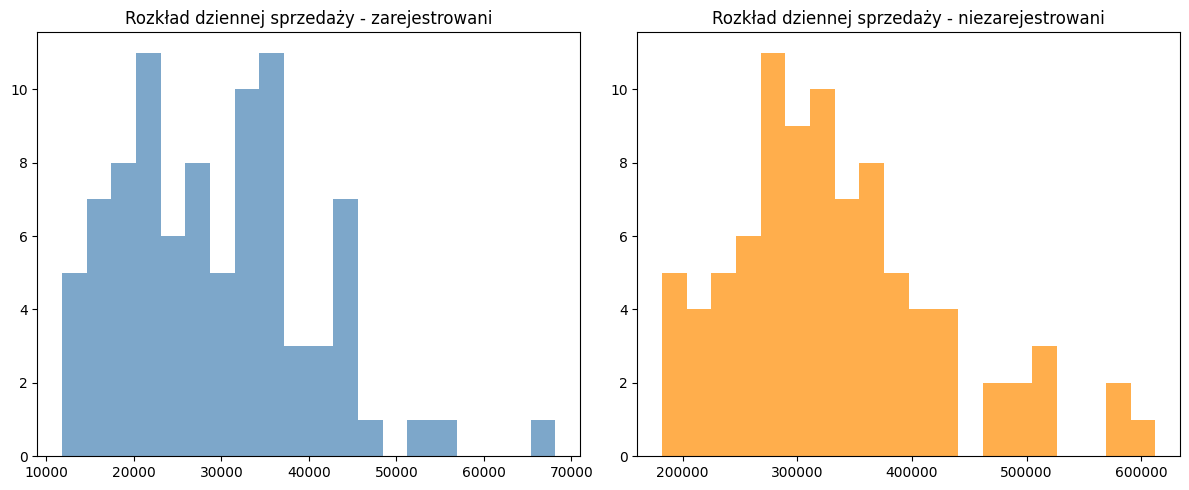


Mann-Whitney U: statystyka=0.000, p-value=0.00000
-> Różnica istotna statystycznie

Kruskal-Wallis (liczba sesji wg kanału): statystyka=352.451, p-value=0.00000
-> Różnice istotne statystycznie

Europa: 23195/65135 sesji organicznych (35.61%)
Ameryka: 68671/193179 sesji organicznych (35.55%)
Z-test proporcji: statystyka=0.290, p-value=0.77219
-> Różnica NIEistotna statystycznie

Mann-Whitney U (wartość zamówienia mobile vs desktop): statystyka=127991217.500, p-value=0.15860
-> Różnica NIEistotna statystycznie


In [33]:
from scipy import stats

# TEST 1: Sprzedaż wg daty - zarejestrowani vs niezarejestrowani

orders_registered = orders_df[orders_df['registered_user_id'].notna()]
orders_unregistered = orders_df[orders_df['registered_user_id'].isna()]

daily_sales_reg = orders_registered.groupby('order_date')['price'].sum()
daily_sales_unreg = orders_unregistered.groupby('order_date')['price'].sum()


all_dates = orders_df['order_date'].unique()
daily_sales_reg = daily_sales_reg.reindex(all_dates, fill_value=0)
daily_sales_unreg = daily_sales_unreg.reindex(all_dates, fill_value=0)


_, p_norm_reg = stats.shapiro(daily_sales_reg)
_, p_norm_unreg = stats.shapiro(daily_sales_unreg)
print(f"Test normalności (Shapiro-Wilk): zarejestrowani p={p_norm_reg:.5f}, niezarejestrowani p={p_norm_unreg:.5f}")

# Wizualizacja rozkładów
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(daily_sales_reg, bins=20, color='steelblue', alpha=0.7)
axes[0].set_title('Rozkład dziennej sprzedaży - zarejestrowani')
axes[1].hist(daily_sales_unreg, bins=20, color='darkorange', alpha=0.7)
axes[1].set_title('Rozkład dziennej sprzedaży - niezarejestrowani')
plt.tight_layout()
plt.show()


if p_norm_reg < 0.05 or p_norm_unreg < 0.05:
    stat, p_value = stats.mannwhitneyu(daily_sales_reg, daily_sales_unreg)
    test_name = "Mann-Whitney U"
else:
    stat, p_value = stats.ttest_ind(daily_sales_reg, daily_sales_unreg)
    test_name = "t-test"

print(f"\n{test_name}: statystyka={stat:.3f}, p-value={p_value:.5f}")
print("-> Różnica istotna statystycznie" if p_value < 0.05 else "-> Różnica NIEistotna statystycznie")


# TEST 2: Liczba sesji wg kanału ruchu (ANOVA lub Kruskal-Wallis)

sessions_unique = df.drop_duplicates(subset='session_id')
channel_groups = [
    sessions_unique[sessions_unique['traffic_channel'] == ch].groupby('order_date')['session_id'].nunique()
    for ch in top_channels
]
channel_groups = [g.reindex(all_dates, fill_value=0) for g in channel_groups]

# Test Kruskala-Wallisa
stat, p_value = stats.kruskal(*channel_groups)
print(f"\nKruskal-Wallis (liczba sesji wg kanału): statystyka={stat:.3f}, p-value={p_value:.5f}")
print("-> Różnice istotne statystycznie" if p_value < 0.05 else "-> Różnice NIEistotne statystycznie")


# TEST 3: % ruchu organicznego - Europa vs Ameryka

sessions_eu = sessions_unique[sessions_unique['continent'] == 'Europe']
sessions_am = sessions_unique[sessions_unique['continent'] == 'Americas']

organic_eu = (sessions_eu['traffic_channel'] == 'Organic Search').sum()
total_eu = len(sessions_eu)
organic_am = (sessions_am['traffic_channel'] == 'Organic Search').sum()
total_am = len(sessions_am)

print(f"\nEuropa: {organic_eu}/{total_eu} sesji organicznych ({organic_eu/total_eu*100:.2f}%)")
print(f"Ameryka: {organic_am}/{total_am} sesji organicznych ({organic_am/total_am*100:.2f}%)")

# Test proporcji
from statsmodels.stats.proportion import proportions_ztest
count = np.array([organic_eu, organic_am])
nobs = np.array([total_eu, total_am])
stat, p_value = proportions_ztest(count, nobs)
print(f"Z-test proporcji: statystyka={stat:.3f}, p-value={p_value:.5f}")
print("-> Różnica istotna statystycznie" if p_value < 0.05 else "-> Różnica NIEistotna statystycznie")


# TEST DODATKOWY: Średnia wartość zamówienia - mobile vs desktop

mobile_orders = orders_df[orders_df['device'] == 'mobile']['price']
desktop_orders = orders_df[orders_df['device'] == 'desktop']['price']

_, p_norm_m = stats.shapiro(mobile_orders.sample(min(len(mobile_orders), 5000)))
_, p_norm_d = stats.shapiro(desktop_orders.sample(min(len(desktop_orders), 5000)))

if p_norm_m < 0.05 or p_norm_d < 0.05:
    stat, p_value = stats.mannwhitneyu(mobile_orders, desktop_orders)
    test_name = "Mann-Whitney U"
else:
    stat, p_value = stats.ttest_ind(mobile_orders, desktop_orders)
    test_name = "t-test"

print(f"\n{test_name} (wartość zamówienia mobile vs desktop): statystyka={stat:.3f}, p-value={p_value:.5f}")
print("-> Różnica istotna statystycznie" if p_value < 0.05 else "-> Różnica NIEistotna statystycznie")

##**Wnioski**
Rozkłady dziennej sprzedaży dla zarejestrowanych i niezarejestrowanych użytkowników nie są normalne (Shapiro-Wilk, p<0,05 w obu grupach). Test Manna-Whitneya wykazał istotną statystycznie różnicę (p<0,00001), widoczną na histogramach, gdzie skale całkowicie się nie pokrywają. Test Kruskala-Wallisa potwierdził istotne statystycznie różnice w liczbie sesji między kanałami ruchu (p<0,00001), co jest zgodne z wcześniej zaobserwowaną dysproporcją między Organic Search a np. Social Search. Odsetek sesji organicznych okazał się niemal identyczny w Europie i Ameryce (35,6% vs 35,55%), a test proporcji nie wykazał istotnej różnicy (p=0,772). Podobnie test porównujący średnią wartość zamówienia między mobile i desktop nie wykazał istotnej różnicy (p=0,159).

In [31]:

# TEST DODATKOWY: Niezależność kanału ruchu i typu urządzenia

contingency_table = pd.crosstab(sessions_unique['traffic_channel'], sessions_unique['device'])
print("Tabela kontyngencji (kanał x urządzenie):\n", contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nTest chi-kwadrat: chi2={chi2:.3f}, p-value={p_value:.5f}, stopnie swobody={dof}")
print("-> Kanał ruchu i typ urządzenia SĄ zależne statystycznie" if p_value < 0.05
      else "-> Kanał ruchu i typ urządzenia są NIEzależne statystycznie")

Tabela kontyngencji (kanał x urządzenie):
 device           desktop  mobile  tablet
traffic_channel                         
Direct             47825   31745    1812
Organic Search     72622   49014    2789
Paid Search        55167   37034    2140
Social Search      16288   10988     638
Undefined          12527    8486     470

Test chi-kwadrat: chi2=4.739, p-value=0.78506, stopnie swobody=8
-> Kanał ruchu i typ urządzenia są NIEzależne statystycznie


##**Wnioski**
Test chi-kwadrat nie wykazał istotnej statystycznie zależności między kanałem ruchu a typem urządzenia (x²=4,739, p=0,785). Innymi słowy, proporcje urządzeń są zbliżone w obrębie każdego kanału ruchu.